In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import sys
import os
import time

# Get the absolute path to the directory containing 'notebooks'
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.simulation import simulate_comb_sbm, simulate_mf_sbm
from src.synthetic_data import generate_sbm_adjacency_matrix
from src.helper_functions import power_law_kernel, rayleigh_kernel, gaussian_kernel, sigmoid_kernel, exponential_kernel

In [3]:
# Parameters for a small two-coommunity example
final_time = 100
num_nodes1 = 500
alphas =  np.array([0.7,0.3]) 
comm_size1 = (num_nodes1 * alphas).astype(int)

prob_matrix = np.array([[0.9, 0.1],
                        [0.1, 0.9]])

exp_params1 = [0.9, 0.5]
exp_params2 = [0.5, 0.1]

kernel_params_matrix = np.array([exp_params1, exp_params2])
kernel_function_matrix = np.array([exponential_kernel, exponential_kernel])


In [ ]:
#Generate adjecency matrix and node community labels
labs, adj_matrix = generate_sbm_adjacency_matrix(comm_size1, prob_matrix)

#Generate from exponential random variable to simulate Poisson rv
E = np.random.exponential(scale = 1.0, size = (final_time, num_nodes1, 100))

#Simulate true intenity (lmbd) and jumps (Y)
_, lmbd_comb ,X_comb = simulate_comb_sbm(E, final_time,num_nodes1,comm_size1, kernel_function_matrix, kernel_params_matrix, adj_matrix, labs, mu_vector = np.array([0.9, 0.5]), lag =1)

In [5]:
#Simulate mean field lambda and associated jumps
_, lmbd_mf, X_mf = simulate_mf_sbm(E, final_time, comm_size1, prob_matrix, kernel_function_matrix, kernel_params_matrix,mu_vector = np.array([0.9, 0.5]), lag =1)

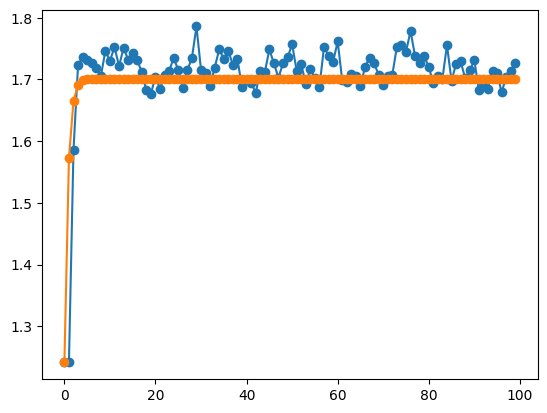

In [9]:
#See if the mean field for a chosen node is close to the true intensity (sanity check)

node_idx = 0

plt.plot(lmbd_comb[:,node_idx], label='Community 1 - COMB', marker='o')
plt.plot(lmbd_mf[:,labs[node_idx]], label='Community 1 - MF', marker = 'o')
plt.show()

In [18]:
from inference import jumps_per_community_over_time, lambda_bar_and_grad_for_all_times, loglik_approx, gradient_descent_fit, objective_and_grad, grad_loglik_intuitive

In [19]:
lag = 1
num_comm =len(alphas)

phi_community_one = np.array([
    [
        exponential_kernel(exp_params1, t),
        exponential_kernel(exp_params2, t),
    ]
    for t in range(1, lag+1)
])

phi_true = np.repeat(phi_community_one[:, None, :], num_comm, axis=1)
mu_true = np.array([0.9, 0.5])

mu0  = np.full(num_comm, 0.5)          # (num_comm,)
phi0 = np.random.uniform(
    0.0, 0.7,
    size=(lag, num_comm, num_comm)
)  

In [20]:
lambda_bar, grad_lambda_bar = lambda_bar_and_grad_for_all_times(
        mu_true, phi_true, alphas, prob_matrix, comm_size2, lag, final_time)

In [21]:
grad_loglik = grad_loglik_intuitive(labs, comm_size1, X_comb, lambda_bar, grad_lambda_bar)
print(grad_loglik)

[-1163.62163389  -453.0898297   -630.93840614   -14.04788877
   -28.54446163   -50.44740298]


In [22]:
print(np.allclose(lmbd_mf, lambda_bar))

True


In [23]:
from inference import gradient_descent_fit_mu_only, gradient_descent_fit_phi_only

In [24]:
mu_hat, phi_hat, mu_iterates, loglik_hist = gradient_descent_fit_mu_only(
   mu0, phi_true, alphas, prob_matrix, comm_size2,
    lag, X_comb, labs,
    lr_mu=1e-7, max_iter=1000
)

iter   20  loglik = 28404.891683  mu = [0.0881097  0.04894654]
iter   40  loglik = 28405.037987  mu = [0.08812965 0.0487392 ]
iter   60  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter   80  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  100  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  120  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  140  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  160  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  180  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  200  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  220  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  240  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  260  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  280  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  300  loglik = 28405.037987  mu = [0.08812966 0.0487391 ]
iter  320  loglik = 28405.037987  mu = [0.08812966 0.04

In [25]:
mu_hat, phi_hat, phi_iterates, loglik_hist = gradient_descent_fit_phi_only(
   mu_true, phi0, alphas, prob_matrix, comm_size2,
    lag, X_comb, labs,
    lr_phi=1e-7, max_iter=1000
)

iter   20  loglik = -992822.630711
iter   40  loglik = -983364.776279
iter   60  loglik = -981560.699829
iter   80  loglik = -979760.832110
iter  100  loglik = -977965.163303
iter  120  loglik = -976173.683613
iter  140  loglik = -974386.383267
iter  160  loglik = -972603.252514
iter  180  loglik = -970824.281628
iter  200  loglik = -969049.460903
iter  220  loglik = -967278.780659
iter  240  loglik = -966973.538159
iter  260  loglik = -966973.538159
iter  280  loglik = -966973.538159
iter  300  loglik = -966973.538159
iter  320  loglik = -966973.538159
iter  340  loglik = -966973.538159
iter  360  loglik = -966973.538159
iter  380  loglik = -966973.538159
iter  400  loglik = -966973.538159
iter  420  loglik = -966973.538159
iter  440  loglik = -966973.538159
iter  460  loglik = -966973.538159
iter  480  loglik = -966973.538159
iter  500  loglik = -966973.538159
iter  520  loglik = -966973.538159
iter  540  loglik = -966973.538159
iter  560  loglik = -966973.538159
iter  580  loglik = 

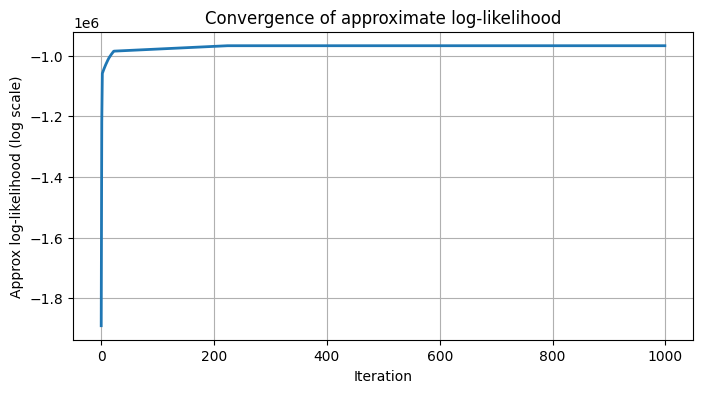

In [26]:
plt.figure(figsize=(8,4))
plt.plot(loglik_hist, lw=2)
#plt.yscale("log")   
plt.xlabel("Iteration")
plt.ylabel("Approx log-likelihood (log scale)")
plt.title("Convergence of approximate log-likelihood")
plt.grid(True)
plt.show()

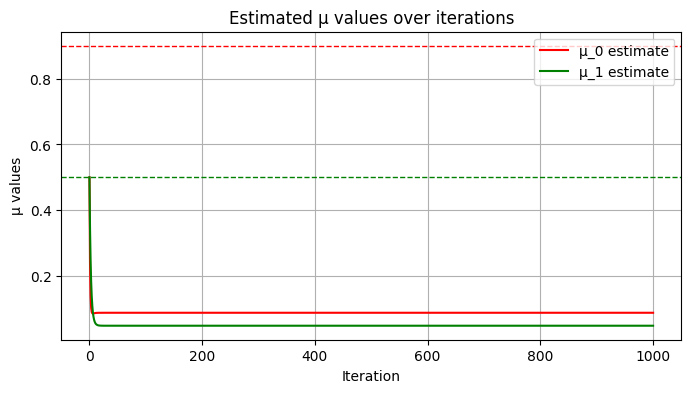

In [27]:
colors = ['r', 'g', 'b']

plt.figure(figsize=(8,4))

for h in range(num_comm):
    plt.plot(mu_iterates[:, h], label=f"μ_{h} estimate", color=colors[h])

# plot true value as horizontal lines
for h in range(num_comm):
    plt.axhline(mu_true[h], color=colors[h], linestyle='--', linewidth=1)

plt.xlabel("Iteration")
plt.ylabel("μ values")
plt.title("Estimated μ values over iterations")
plt.legend()
plt.grid(True)
plt.show()


0.5458775937413701
0.45241870901797976


/tmp/ipykernel_343215/1167883876.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_comm * 2)


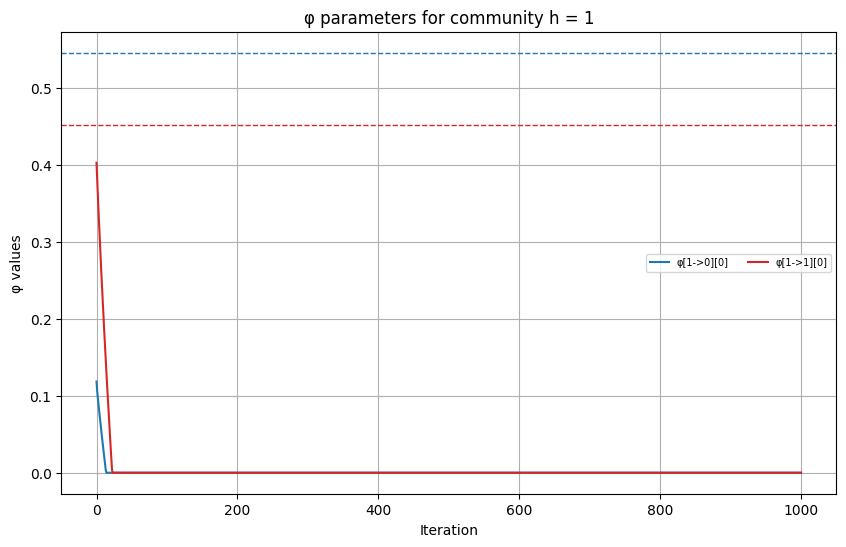

In [46]:
h = 1
plt.figure(figsize=(10,6))

# get a colormap with enough distinct colors
cmap = plt.cm.get_cmap("tab20", num_comm * 2)

color_index = 0

for r in range(num_comm):
    for m in range(1):
        color = cmap(color_index)
        color_index += 1

        # estimated trajectory
        plt.plot(
            phi_iterates[:, m, h, r],
            label=f"φ[{h}->{r}][{m}]",
            color=color
        )

        # true value (same color, dashed)
        plt.axhline(
            phi_true[m, h, r],
            linestyle="--",
            linewidth=1,
            color=color
        )
        print(phi_true[m, h, r])

plt.xlabel("Iteration")
plt.ylabel("φ values")
plt.title(f"φ parameters for community h = {h}")
plt.legend(ncol=4, fontsize=7)
plt.grid(True)
plt.show()


### Approach 2 

In [36]:
from inference import compute_d,  compute_k, build_M, compute_J_ultra_optimized, compute_nu_given_inputs, compute_nu_given_inputes_vectorized

In [37]:
p = 1

d = compute_d(X_comb, adj_matrix, p)
print("d computed")
k = compute_k(X_comb, adj_matrix, p)
print("k computed")
J = compute_J_ultra_optimized(X_comb, adj_matrix, p)
print("J list computed")
M = build_M(comm_size1, p)
print("M computed")

print("Starting mu computation")
mus = compute_nu_given_inputs(d, k, J, M, labs, X_comb, comm_size1)

d computed
k computed


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [45]:
mus[0]

array([-7.84768726e-01, -1.32730640e-03,  3.42081227e-04])

In [44]:
mus[1]

array([-8.22727130e-01, -2.91351693e-04,  2.04084099e-04])